# Credit Risk Prediction

Objective:
Predict whether a customer will experience serious delinquency within the next two years using historical credit information.

Dataset:
Kaggle - Give Me Some Credit

### 2. Imports

In [58]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
from joblib import dump
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

### 3. Load data

In [ ]:
DATA_PATH = Path("../data/raw")

train_df = pd.read_csv(DATA_PATH / "cs-training.csv")
train_df = train_df.drop(columns="Unnamed: 0")

### 4. Exploratory Data Analysis

Columns
* RevolvingUtilizationOfUnsecuredLines
* age
* NumberOfTime30-59DaysPastDueNotWorse
* DebtRatio
* MonthlyIncome
* NumberOfOpenCreditLinesAndLoans
* NumberOfTimes90DaysLate
* NumberRealEstateLoansOrLines
* NumberOfTime60-89DaysPastDueNotWorse
* NumberOfDependents

#### Target distribution

In [29]:
# Target distribution shows imbalance
target = 'NumberOfTime60-89DaysPastDueNotWorse'
distribution = pd.DataFrame({
    'Count': train_df[target].value_counts(),
    'Percentage': train_df[target].value_counts(normalize=True) * 100
})

print(distribution)

                                       Count  Percentage
NumberOfTime60-89DaysPastDueNotWorse                    
0                                     142396   94.930667
1                                       5731    3.820667
2                                       1118    0.745333
3                                        318    0.212000
98                                       264    0.176000
4                                        105    0.070000
5                                         34    0.022667
6                                         16    0.010667
7                                          9    0.006000
96                                         5    0.003333
8                                          2    0.001333
11                                         1    0.000667
9                                          1    0.000667


#### Missing values

In [11]:
# Missing values on df
print("Columns with missing values")
for i in train_df.columns:
    missing_percentage = (train_df[i].isna().mean() * 100).round(2)
    if missing_percentage > 0:
        print(f"Missing percentage on {i}: {missing_percentage}%")

Columns with missing values
Missing percentage on MonthlyIncome: 19.82%
Missing percentage on NumberOfDependents: 2.62%


#### Histograms

In [42]:
def plot_distribution(series, bins=30, clip_quantile=0.99):
    """
    Plots a histogram and boxplot, clipping extreme values
    only for visualization.

    Parameters
    ----------
    series : pd.Series
    bins : int
        Number of histogram bins.
    clip_quantile : float
        Upper quantile used for plotting (e.g. 0.99 = 99th percentile).
    """
    s = series.dropna()

    # Clip only for visualization
    upper = s.quantile(clip_quantile)
    lower = s.quantile(1 - clip_quantile) if clip_quantile < 0.5 else s.min()

    s_plot = s[(s >= lower) & (s <= upper)]

    fig, ax = plt.subplots(
        2, 1,
        figsize=(8, 5),
        gridspec_kw={"height_ratios": [1, 4]}
    )

    # Boxplot
    ax[0].boxplot(
        s,
        orientation='horizontal',
        showfliers=False
    )
    ax[0].set_title(series.name)

    # Histogram
    ax[1].hist(s_plot, bins=bins, edgecolor="black")
    ax[1].set_xlabel(series.name)
    ax[1].set_ylabel("Count")
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Showing up to the {clip_quantile:.0%} percentile")
    print(f"Max plotted: {upper:.3f}")
    print(f"Actual max : {s.max():.3f}")

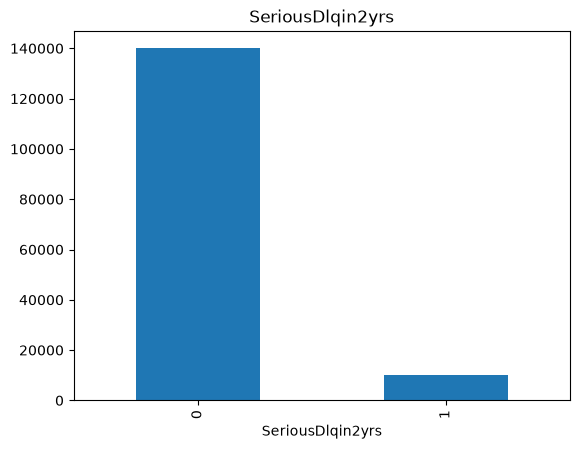

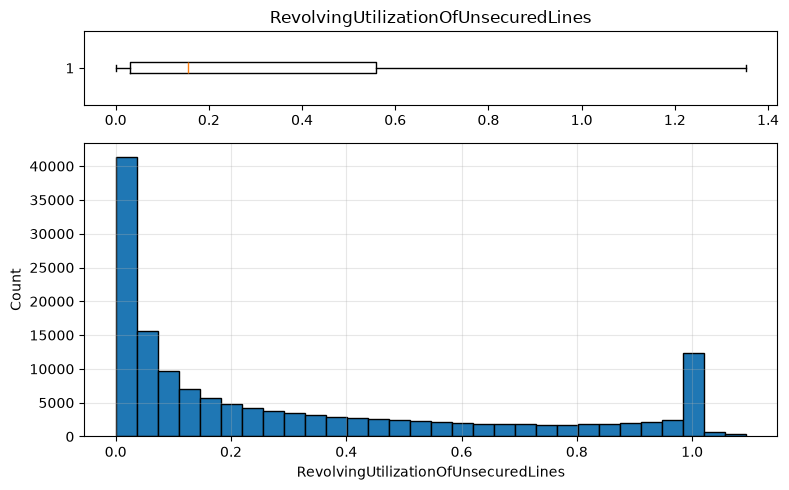

Showing up to the 99% percentile
Max plotted: 1.093
Actual max : 50708.000


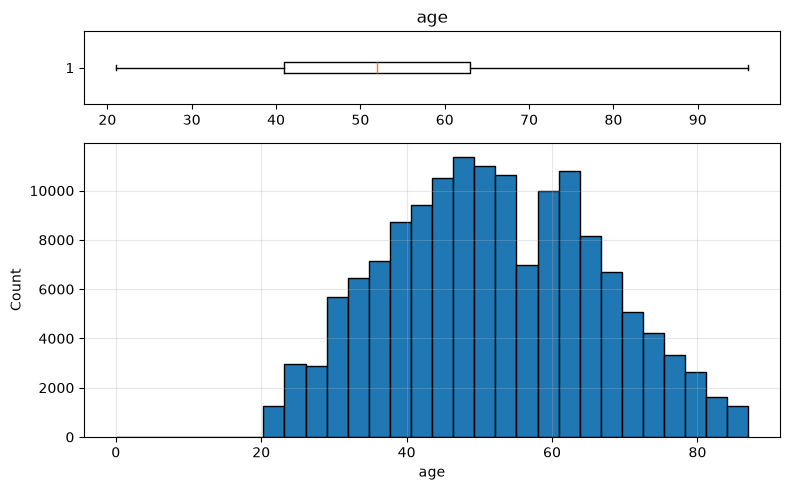

Showing up to the 99% percentile
Max plotted: 87.000
Actual max : 109.000


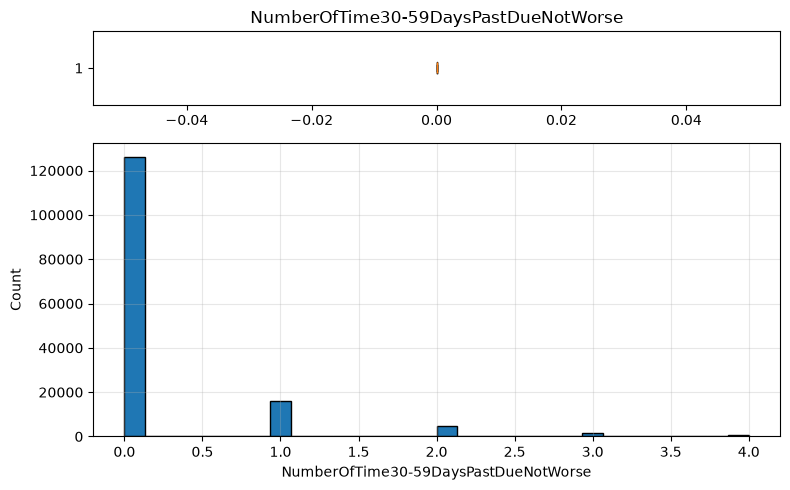

Showing up to the 99% percentile
Max plotted: 4.000
Actual max : 98.000


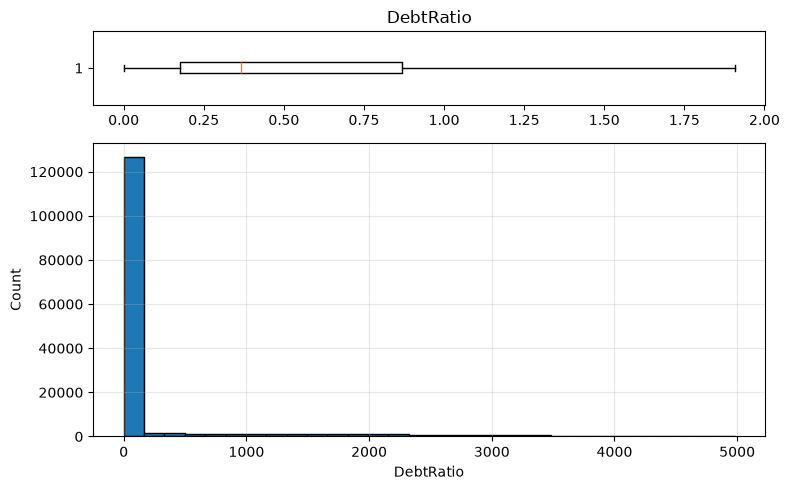

Showing up to the 99% percentile
Max plotted: 4979.040
Actual max : 329664.000


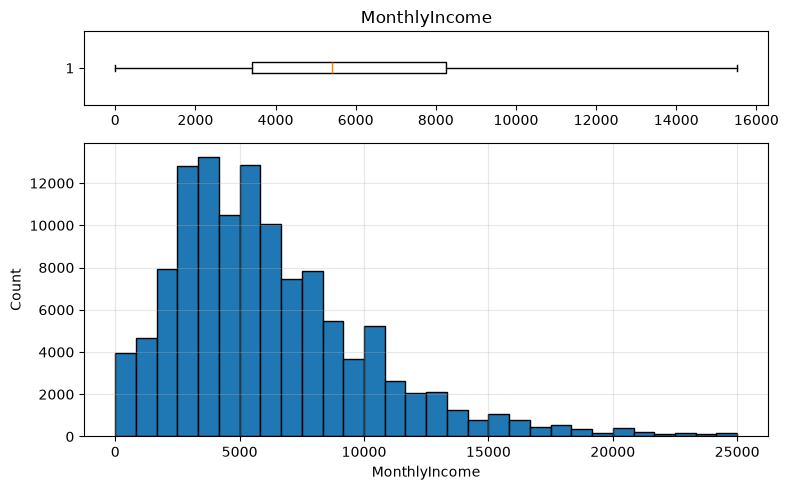

Showing up to the 99% percentile
Max plotted: 25000.000
Actual max : 3008750.000


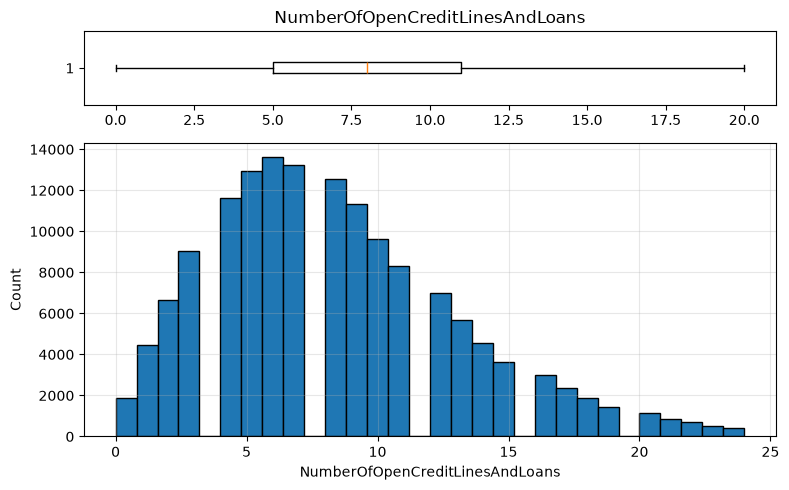

Showing up to the 99% percentile
Max plotted: 24.000
Actual max : 58.000


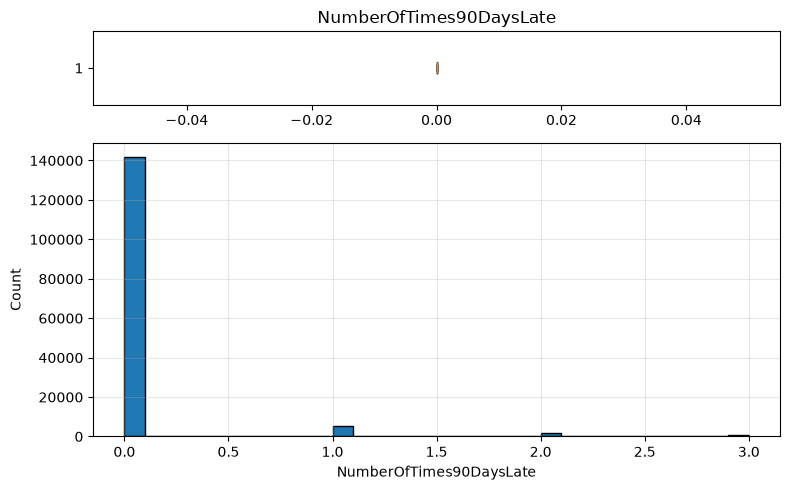

Showing up to the 99% percentile
Max plotted: 3.000
Actual max : 98.000


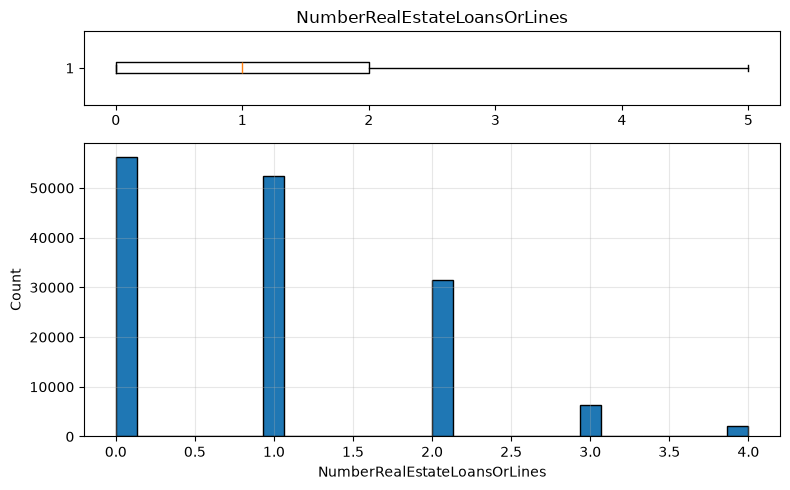

Showing up to the 99% percentile
Max plotted: 4.000
Actual max : 54.000


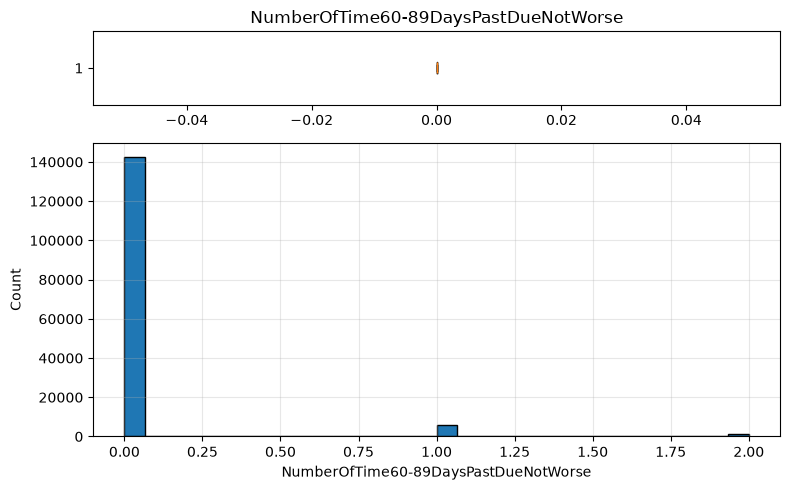

Showing up to the 99% percentile
Max plotted: 2.000
Actual max : 98.000


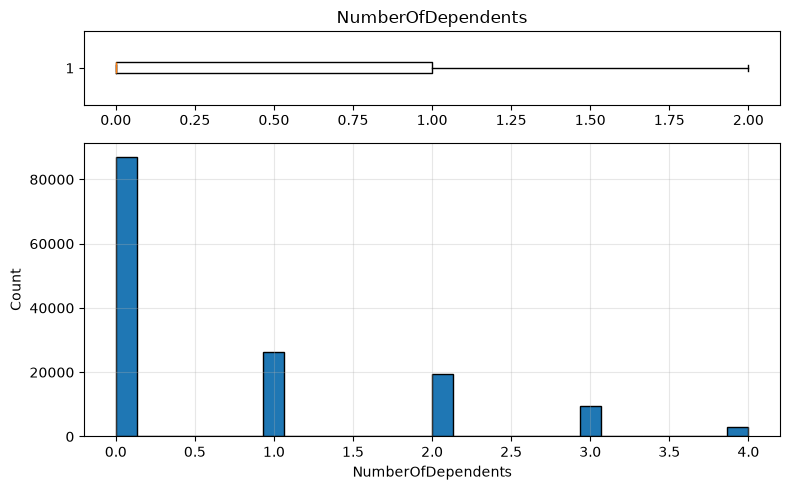

Showing up to the 99% percentile
Max plotted: 4.000
Actual max : 20.000


In [44]:
for col in train_df.select_dtypes(include="number").columns:
    if train_df[col].nunique() > 5:
        plot_distribution(train_df[col])
    else:
        train_df[col].value_counts().sort_index().plot.bar()
        plt.title(col)
        plt.show()

### 5. Data cleaning and preprocessing

#### Preprocessors

In [45]:
class CreditPreprocessor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.monthly_income_median_ = X["MonthlyIncome"].median()
        return self

    def transform(self, X):
        X = X.copy()

        # Missing MonthlyIncome indicator
        X["MissingMI"] = X["MonthlyIncome"].isna().astype(int)

        # Impute MonthlyIncome with median
        X["MonthlyIncome"] = X["MonthlyIncome"].fillna(
            self.monthly_income_median_
        )

        # Impute NumberOfDependents with 0
        X["NumberOfDependents"] = X["NumberOfDependents"].fillna(0)

        return X

In [52]:
X_train = train_df.drop(columns="SeriousDlqin2yrs")
y_train = train_df['SeriousDlqin2yrs']

preprocessor = Pipeline([
    ("credit", CreditPreprocessor()),
    ("scaler", StandardScaler()),
])

X_train_processed = preprocessor.fit_transform(X_train)

In [53]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42,
)

In [54]:
param_dist = {
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [None, 3, 5, 7, 10],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [10, 20, 50, 100],
    "l2_regularization": [0, 0.01, 0.1, 1],
    "max_iter": [100, 200, 300, 500],
}

search = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2,
)

search.fit(X_tr, y_tr)

print("Best ROC AUC:", search.best_score_)
print("Best params:")
print(search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best ROC AUC: 0.864121516246777
Best params:
{'min_samples_leaf': 100, 'max_leaf_nodes': 15, 'max_iter': 100, 'max_depth': 10, 'learning_rate': 0.1, 'l2_regularization': 0}


In [55]:
best_model = search.best_estimator_

from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    best_model,
    method="isotonic",
    cv=3,
)

calibrated_model.fit(X_tr, y_tr)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",HistGradientB...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...00226550A48F0>, <s

In [56]:
y_proba = calibrated_model.predict_proba(X_val)[:, 1]
y_pred = calibrated_model.predict(X_val)
threshold = 0.737
y_pred = (y_proba >= threshold).astype(int)

In [57]:
print(f"Accuracy : {accuracy_score(y_val, y_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_pred):.4f}")
print(f"Recall   : {recall_score(y_val, y_pred):.4f}")
print(f"F1-score : {f1_score(y_val, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_val, y_proba):.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_val, y_pred))

print("\nClassification Report")
print(classification_report(y_val, y_pred))

Accuracy : 0.9339
Precision: 0.7619
Recall   : 0.0160
F1-score : 0.0313
ROC AUC  : 0.8684

Confusion Matrix
[[27985    10]
 [ 1973    32]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      1.00      0.97     27995
           1       0.76      0.02      0.03      2005

    accuracy                           0.93     30000
   macro avg       0.85      0.51      0.50     30000
weighted avg       0.92      0.93      0.90     30000



In [60]:
dump(calibrated_model, "../models/calibrated_model.joblib")

['../models/calibrated_model.joblib']

### 10. Testing output

In [66]:
test_df = pd.read_csv(DATA_PATH / "cs-test.csv")
X_test = test_df.drop(columns="Unnamed: 0")
X_test = X_test.to_numpy()

In [67]:
# Predicted class (0 or 1)
y_pred = calibrated_model.predict(X_test)

# Predicted probability of the positive class
y_prob = calibrated_model.predict_proba(X_test)[:, 1]

In [69]:
submission = pd.DataFrame({
    "Id": range(1, len(y_prob) + 1),
    "Probability": y_prob
})

submission.to_csv("submission.csv", index=False)